In [ ]:
# V1: Designed to produce cutouts from images (CAL or MER) or MER tiles, then to apply bright source masking.

In [ ]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.visualization import PercentileInterval, AsinhStretch, ImageNormalize, wcsaxes, ZScaleInterval
from astropy.wcs import WCS, utils
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from photutils.background import Background2D, MedianBackground
from astropy.convolution import convolve, Gaussian2DKernel
from photutils.segmentation import make_2dgaussian_kernel, detect_sources, deblend_sources, detect_threshold
import pandas as pd
from photutils.aperture import SkyCircularAperture, aperture_photometry
import glob
from astropy.cosmology import Planck18 as cosmo

from astropy.visualization.wcsaxes import SphericalCircle
from matplotlib.patches import Polygon


from astropy.table import QTable
from photutils.utils import circular_footprint
from scipy.ndimage import binary_dilation

from nicl.filter import sampled_mad_filter
from nicl.hsc.preparation import f21_cluster_image, find_field, get_f21_table2
from nicl.utilities import (
    calc_sb_threshold,
    distance_from_coord,
    get_img_centre_pixel,
    get_img_centre_world,
    get_pixel_scale,
    physical_to_angular,
    sb_to_adu,
)

h=0.7
cosmo=FlatLambdaCDM(H0=h*100, Om0=0.3)

/opt/anaconda3/envs/icl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

def calculate_cutout_size(z, cutout_radius_kpc=1000, output_unit='arcmin'):
    """
    Calculates the cutout size and radius based on cluster redshift with options for output units and cutout radius.

    Parameters:
    - z: float, redshift of the cluster.
    - cutout_radius_kpc: float, the cutout radius in kiloparsecs.
    - output_unit: strength, the unit for output, either 'arcsec',  'arcmin' or 'deg'.
    
    Return:
    - dict: Contains cutout size and radius in output units.
    """

    cutout_radius_kpc = cutout_radius_kpc * u.kpc
    cutout_size_kpc = 2 * cutout_radius_kpc #one side of the cutout


    arcsec_per_kpc = cosmo.arcsec_per_kpc_proper(z)
    cutout_size_arcsec = cutout_size_kpc * arcsec_per_kpc
    cutout_radius_arcsec = cutout_radius_kpc * arcsec_per_kpc

    if output_unit == 'deg':
        cutout_size = cutout_size_arcsec.to(u.deg)
        cutout_radius = cutout_radius_arcsec.to(u.deg)
        
    else: 
        cutout_size = cutout_size_arcsec.to(u.arcmin)
        cutout_radius = cutout_radius_arcsec.to(u.arcmin)

    return {"Cutout_Size": cutout_size, "Cutout_Radius": cutout_radius}

def get_cutout_and_save(image_path, cutout_size, output_path, cutout_name, source='MER', ra=None, dec=None):
    """
    Extracts and returns a cutout image from a given larger image.

    Parameters:
    - image_path: Full directory of the input FITS file containing the image data.
    - cutout_size: Side length of the cutout (can be in degrees (u.deg) or other angular units (u.arcmin or u.arcsec), will be converted to degrees).
    - output_path: Directory where the cutout image will be saved.
    - cutout_name: Name of the output file.
    - source : 'MER' or 'CAL' indicating image is either from MER mosaics or from Calibrated images.
    - ra: (Optional) RA of the cutout center (in degrees). Default is to read the FITS header value if not provided.
    - dec: (Optional) Dec of the cutout center (in degrees). Default is to read the FITS header value if not provided.

    Returns:
    - position: SkyCoord object representing the center of the cutout.
    - cutout_data: 2D array of the cutout image data.
    - cutout_header: FITS header of the cutout.
    - cutout_wcs: WCS object for the cutout.
    """
    with fits.open(image_path, memmap=True) as hdul:
        if source == 'MER':
            data = hdul[0].data
            header = hdul[0].header
            wcs = WCS(header)
            
        if source == 'CAL':        
            data = hdul[1].data
            header = hdul[1].header
            wcs = WCS(header)

        if ra is None or dec is None:
            ra = header['CRVAL1']
            dec = header['CRVAL2']

        position = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame='icrs')

        size = u.Quantity((cutout_size, cutout_size), u.deg)

        cutout = Cutout2D(data, position, size, wcs=wcs)
        cutout_data = cutout.data
        cutout_header = cutout.wcs.to_header()
        cutout_wcs = WCS(cutout_header)

        hdu = fits.PrimaryHDU(data=cutout.data, header=cutout_header)
        hdu.writeto(f"{output_path}/{cutout_name}", overwrite=True)

        print(f"Cutout saved to {output_path}/{cutout_name}")

        return position, cutout_data, cutout_header, cutout_wcs



def show_image(image_data, image_wcs, ra=None, dec=None, radius=None, intervalpc=95, outline_shape=None):
    """
    Displays an image and optionally outlines a region around a given RA, Dec.
    Parameters:
    - image_data: 2D array of the image data to display.
    - image_wcs: WCS object associated with the image.
    - ra: Right Ascension of the center (in degrees) for the region to outline.
    - dec: Declination of the center (in degrees) for the region to outline.
    - radius: radius of the circle which will be outlined (can be 'arcsec', 'arcmin' or 'deg', if none given assumes 'deg'). Alternatively, if 'box' is selected radius defines the half side length.
    - intervalpc: Percentile interval for image normalization (default 95).
    - outline_shape: Shape of the region to outline ('circle' or 'box').

    Warning: If you want to display a random image, without calculating the cutout size as in the framework of this script, 
    ensure the units of the radius are embedded within the given parameter (custom radius *u.deg or *u.arcmin). If not the code assumes it is in degrees. 
    """

    interval = PercentileInterval(intervalpc)
    norm = ImageNormalize(image_data, interval=interval, stretch=AsinhStretch())

    fig, ax = plt.subplots(subplot_kw={'projection': image_wcs})
    im = ax.imshow(image_data, norm=norm, origin='lower', cmap='Greys', interpolation='nearest')

    if ra is not None and dec is not None:
        Centre = SkyCoord(ra=ra * u.degree, dec=dec * u.degree, frame='icrs')

        ax.scatter(Centre.ra.deg, Centre.dec.deg, marker='x', s=50, c='red', transform=ax.get_transform('fk5'))

        if outline_shape == 'circle' and radius is not None:
            circle = SphericalCircle((Centre.ra, Centre.dec), radius, edgecolor='cyan', facecolor='none',
                                     transform=ax.get_transform('fk5'))
            ax.add_patch(circle)
            
        elif outline_shape == 'box' and radius is not None:
            radius_deg = radius.to(u.deg).value if isinstance(radius, u.Quantity) else radius
        
            # Scaling RA offset by cos(Dec) to ensure equal angular side lengths
            ra_offset = radius_deg / np.cos(np.radians(dec))
        
            corners = [
                (ra - ra_offset, dec - radius_deg),  # Bottom-left
                (ra - ra_offset, dec + radius_deg),  # Top-left
                (ra + ra_offset, dec + radius_deg),  # Top-right
                (ra + ra_offset, dec - radius_deg),  # Bottom-right
            ]
        
            poly = Polygon(
                corners, closed=True, edgecolor='yellow', facecolor='none',
                transform=ax.get_transform('fk5')
            )
            ax.add_patch(poly)
            
    plt.colorbar(im, ax=ax, orientation='vertical', label='Pixel Intensity')
    plt.xlabel("RA (J2000)")
    plt.ylabel("Dec (J2000)")
    plt.show()


In [ ]:
def estimate_local_background(image_data , kernel_size=10, filter_size=11, intervalpc=95, plot:bool=False):   
    """
    Estimates a median background using given kernel and filter sizes.

    Parameters: 
    - image_data: 2D array of the image data to display.
    - kernel_size: default=9, the size of the kernel for the background estimation.
    - filter_size: default=11, the size of the filter for smoothing.
    - plot: bool, default=False, whether to plot the results.

    Returns:
    - bkg_image: 2D array, the estimated background image.
    - bkg_image_rms: 2D array, the RMS of the background.
    - bkg_subtracted_image: 2D array, the background-subtracted image.
    
    """
    
    bkg_estimator = MedianBackground()
    bkg = Background2D(image_data, (kernel_size, kernel_size), filter_size=(filter_size, filter_size), bkg_estimator=bkg_estimator)
    # print(bkg)
    bkg_image = bkg.background
    bkg_image_rms = bkg.background_rms
    bkg_subtracted_image = image - bkg.background

    if plot:
        
        fig, ax = plt.subplots(1, 4, figsize=(16, 5))
        
        interval = PercentileInterval(intervalpc)
        norm = ImageNormalize(image, interval=interval, stretch=AsinhStretch(0.01))

        cmap = 'viridis'
        im0 = ax[0].imshow(image, norm=norm, origin="lower", cmap=cmap)
        ax[0].set_title("Original Image")

        im1 = ax[1].imshow(bkg_image, norm=norm, origin="lower", cmap=cmap)
        ax[1].set_title("Local Background")
        
        norm2 = ImageNormalize(vmin=-0.01, vmax=10, stretch=AsinhStretch(0.01))

        im2 = ax[2].imshow(bkg_image_rms, norm=norm2, origin="lower", cmap=cmap)
        ax[2].set_title("Background RMS")

        im3 = ax[3].imshow(bkg_subtracted_image, norm=norm2, origin="lower", cmap=cmap)
        ax[3].set_title("Background subtracted Image")

        fig.colorbar(im0, ax=ax[0], orientation='vertical', fraction=0.046, pad=0.04)
        fig.colorbar(im1, ax=ax[1], orientation='vertical', fraction=0.046, pad=0.04)
        fig.colorbar(im2, ax=ax[2], orientation='vertical', fraction=0.046, pad=0.04)
        fig.colorbar(im3, ax=ax[3], orientation='vertical', fraction=0.046, pad=0.04)

        for a in ax:
            a.axis("off")
        plt.tight_layout()
    
    return bkg_image, bkg_image_rms, bkg_subtracted_image



def image_threshold_convolution(bkg_image, bkg_image_rms, bkg_subtracted_image, threshold_factor, FWHM, kernel_size=9, plot:bool=False):
    """
    Applies thresholding and convolution to the background-subtracted image for object detection.

    Parameters:
    - bg_image: 2D array of the background image.
    - bg_image_rms: 2D array of the RMS of the background.
    - bg_subtracted_image: 2D array of the background-subtracted image.
    - threshold_factor: float or int, the number of standard deviations above the background for defining the detection threshold.
    - FWHM: float or int, the FWHM for the Gaussian convolution kernel.
    - kernel_size: int, optional, size of the Gaussian kernel (default=9).
    - plot: bool, optional, whether to plot the detection image (default=False).

    Returns:
    - threshold: 2D array, the computed detection threshold for the image.
    - convolved_data: 2D array, the background-subtracted image after Gaussian convolution.
     """                                             
    
    # threshold = detect_threshold(image, nsigma=threshold_factor, background=bg_image, error=bg_image_rms)
    threshold = threshold_factor * bkg_image_rms
    kernel = make_2dgaussian_kernel(FWHM, size=kernel_size)
    convolved_data = convolve(bkg_subtracted_image, kernel)

    if plot:
        fig, ax = plt.subplots(1, 1, figsize=(4, 4))
        norm = ImageNormalize(vmin=-0.01, vmax=10, stretch=AsinhStretch(0.01))
        cmap = 'viridis'
        im = ax.imshow(convolved_data, norm=norm, origin="lower", cmap=cmap)
        ax.set_title("Detection Image")
        ax.axis("off")
        plt.tight_layout()

    return threshold, convolved_data

#### Functions for different masks

In [ ]:

def create_bcg_mask(image, sb_threshold, wcs, bcg_pos=None):
    segm = detect_sources(data=image, threshold=sb_threshold, npixels=6)
    if bcg_pos is None:
        bcg_pos = get_img_centre_pixel(image).astype(int)
    elif wcs is not None:
        # Convert (RA, Dec) to pixel coordinates
        skycoord = SkyCoord(ra=bcg_pos[0] * u.deg, dec=bcg_pos[1] * u.deg, frame='icrs')
        bcg_pos = wcs.world_to_pixel(skycoord)
    else:
        raise ValueError("WCS must be provided when using RA/Dec coordinates for bcg_pos.")

    y, x = int(bcg_pos[1]), int(bcg_pos[0])
    bcg_label = segm.data[y, x]
    bcg_mask = segm.data == bcg_label

    return bcg_mask
    

def sb_to_adu(sb, pix_scale, zp= 29.94 * u.ABmag):
    # Assuming sb is a surface brightness in ABmag/arcsec^2, input as a dimensionless value
    sb_to_mag = sb * u.mag - 2.5 * np.log10(pix_scale.to(u.arcsec).value ** 2) * u.mag
    counts = 10 ** (-(sb_to_mag - zp).value / 2.5)
    return counts


def dilated_object_mask(segm, growth=0.5, verbose=False):
    segm = segm.copy()
    obj_mask = binary_dilation(segm.data > 0)
    if growth > 0:
        size_min = 2
        while True:
            area_min = np.pi * size_min**2
            if verbose:
                print(f"Current minimum size is {size_min} pixels")
            small_labels = segm.labels[segm.areas < area_min]
            if verbose:
                print(f"Removing {len(small_labels)} segments smaller than {area_min} pixels")
            segm.remove_labels(small_labels)
            if verbose:
                print(f"{len(segm.labels)} segments remaining")
            if len(segm.labels) == 0:
                break
            radius = min(9, max(1, int(np.sqrt(size_min * growth))))
            iterations = max(1, int(size_min * growth / radius))
            if verbose:
                print(f"Applying {iterations} iterations of dilation with a radius of {radius}")
            big_mask = binary_dilation(
                segm.data > 0,
                structure=circular_footprint(radius),
                iterations=iterations,
            )
            obj_mask = obj_mask | big_mask
            if verbose:
                print(f"Currently {obj_mask.sum()} pixels masked")
            size_min *= 2
    return obj_mask


def create_object_mask(image, bcg_mask=None, params=None, plot=False):
    """
    Main object mask.
    Creates an object mask using background estimation, thresholding, and convolution.

    Parameters:
    - image: 2D array of the input image.
    - bcg_mask: Optional 2D array, mask for background galaxy clusters (default=None).
    - params: dictionary containing all parameters for background estimation, thresholding, and mask creation.
        - kernel_size: int, size of the kernel for background estimation and convolution.
        - filter_size: int, size of the filter for background smoothing.
        - threshold_factor: float or int, factor for thresholding.
        - FWHM: float, FWHM for the convolution kernel.
        - pixel_connectivity: int, number of connected pixels for source detection.
        - growth: float, or int, growth factor for dilating the object mask.
    - plot: bool, whether to plot intermediate results from other functions (overrides params["plot"] if provided).

    Returns:
    - obj_mask: 2D array of the generated object mask.
    """

    if params is None:
        raise ValueError("The 'params' dictionary must be provided with all required keys.")

    # Background estimation and subtraction
    bkg_image, bkg_image_rms, bgsub = estimate_local_background(
        image,
        kernel_size= 10,
        filter_size=params["filter_size"],
        plot=params["plot"])

    # Create detection image
    threshold, detection_image = image_threshold_convolution(
        bkg_image,
        bkg_image_rms,
        bgsub,
        threshold_factor=params["threshold_factor"],
        FWHM=params["FWHM"],
        kernel_size=params["kernel_size"],
        plot=params["plot"])

    # Detect sources
    segm = detect_sources(
        detection_image,
        threshold,
        npixels=params["pixel_connectivity"])
    
    # Deblend sources
    segm_deblend = deblend_sources(
        detection_image,
        segm,
        npixels=params["pixel_connectivity"],
        nlevels=32,
        contrast=0.001,
        progress_bar=False)


    # Optionally, BCG mask can be removed
    if bcg_mask is not None:
        segm_deblend.remove_masked_labels(bcg_mask)

    obj_mask = dilated_object_mask(
        segm_deblend,
        growth=params["growth"])

    
    fig, ax = plt.subplots(1, 2, figsize=(8, 5))

    im0 = ax[0].imshow(segm, cmap=segm.cmap, origin="lower")
    ax[0].set_title("Segmentation Map")

    im1 = ax[1].imshow(segm_deblend, cmap=segm_deblend.cmap, origin="lower")
    ax[1].set_title("Segmentation Deblended")

    fig.colorbar(im0, ax=ax[0], orientation='vertical', fraction=0.046, pad=0.04)
    fig.colorbar(im1, ax=ax[1], orientation='vertical', fraction=0.046, pad=0.04)

    for a in ax:
        a.axis("off")
        plt.tight_layout()
    return obj_mask


def create_faint_mask(image, object_mask, bcg_mask):
    bkg, rms = sampled_mad_filter(image.data, size=50, nsample=None, gaussian_sigma=20)
    threshold = detect_threshold(image.data, nsigma=3, background=bkg, error=rms)
    detection_image = smooth_image(image, sigma=1)
    
    segm = detect_sources(
        data=detection_image,
        threshold=threshold,
        npixels=5,
    )
    
    segm_deblend = deblend_sources(
        detection_image,
        segm,
        npixels=5,
        nlevels=128,
        contrast=0.01,
        progress_bar=False,
    )
    
    # segm_deblend.remove_masked_labels(bcg_mask)  # remove bcg region
    
    segm_deblend.remove_masked_labels(object_mask, partial_overlap=False)
    faint_mask = segm_deblend.data > 0
    faint_mask = binary_dilation(faint_mask)
    return faint_mask, bkg, rms


def plot_mask(img, mask,intervalpc=95, outputDir=None,plotname=None):
    fig, ax = plt.subplots(1, 3, figsize=(12, 5))
    
    interval = PercentileInterval(intervalpc)
    norm = ImageNormalize(img, interval=interval, stretch=AsinhStretch())
    
    norm = ImageNormalize(vmin=-0.01, vmax=10, stretch=AsinhStretch(0.01))

    im0 = ax[0].imshow(img, norm=norm, origin="lower")
    ax[0].set_title("Original Image")
    
    im1 = ax[1].imshow(np.where(mask, 0, img), norm=norm, origin="lower")
    ax[1].set_title("Masked Image")

    im2 = ax[2].imshow(mask, origin="lower", cmap='viridis')
    ax[2].set_title("Object Mask")

    fig.colorbar(im0, ax=ax[0], orientation='vertical', fraction=0.046, pad=0.04)
    fig.colorbar(im1, ax=ax[1], orientation='vertical', fraction=0.046, pad=0.04)
    fig.colorbar(im2, ax=ax[2], orientation='vertical', fraction=0.046, pad=0.04)

    for a in ax:
        a.axis("off")

    plt.tight_layout()
    # plt.savefig(f"{outputDir}/{plotname}")


def smooth_image(image, sigma):
    kernel = Gaussian2DKernel(sigma)
    kernel.normalize()
    smoothed = convolve(image.data, kernel)
    return smoothed


def save_masked_images_and_mask(
    image, mask, wcs, params, output_dir, cluster_name, obs_source
):
    """ 
    Save masked image and mask to output folder.
    Parameters:
        image: The input image array.
        mask: The mask array (boolean or binary).
        wcs: The WCS object for the image.
        params: Dictionary defined with parameters
        output_dir: Directory where the files will be saved.
        cluster_name: Name of the cluster to be added to the file names.
    """
    
    masked_image = np.where(mask, np.nan, image)
    wcs_header = wcs.to_header()

    # Save the masked image
    masked_image_path = (
        f"{output_dir}masked_image_{cluster_name}_growth_{params['growth']}"
        f"_FWHM_{params['FWHM']}_thf_{params['threshold_factor']}"
        f"_pc_{params['pixel_connectivity']}.fits"
    )
    hdu_image = fits.PrimaryHDU(data=masked_image, header=wcs_header)
    hdu_image.writeto(masked_image_path, overwrite=True)
    print(f"Masked image saved to: {masked_image_path}")

    # Save the mask
    mask_path = (
        f"{output_dir}mask_{cluster_name}_{obs_source}_growth_{params['growth']}"
        f"_FWHM_{params['FWHM']}_thf_{params['threshold_factor']}"
        f"_pc_{params['pixel_connectivity']}.fits"
    )
    hdu_mask = fits.PrimaryHDU(data=mask.astype(int), header=wcs_header)  # Save mask as integers (0 or 1)
    hdu_mask.writeto(mask_path, overwrite=True)
    print(f"Mask saved to: {mask_path}")




## Example of the flow. 

### 1a) Optional: Calculate a cutout size based on a desired radius in kpc.
##### This radius will be converted into degrees based on cluster redshift. It will then be passed into the next function which creates cutouts. If desired, a custom cutout size can be provided directly in degrees, arcsec or arcmin. 

### 1b) Produce the cutout. 
##### If working on a cluster, please try to set both coordinate sets (RA, Dec, BCG_RA and BCG_Dec) to the coordinates of the BCG. You can set the two RAs and Decs to the same values. Alternatively, you can also give different coordinates for the cluster centre and BCG. The BCG centre will be taken in for the BCG mask, but the image will be centered at the given central coordinates. 
##### If working on a field, just any RA and Dec will work, and the cutout will be around that centre. However, 

In [ ]:
cluster_data = {
    "cluster_id": "MCXC J1806.9+6537",
    "z": 0.2,  # Cluster redshift
    "RA": 268.8240562, # Right Ascension of the cluster centre, or BCG if known 
    "Dec":66.6909137,  # Declination of the clsuter centre, or BCG if known 
    "BCG_RA":268.8240562, # Right Ascension of the BCG if known.
    "BCG_Dec":268.8240562, # Declination of the BCG if known. 
    "cutout_radius_kpc": 1000  # Desired radius from the cluster centre in kpc, size will be twice of this.
}


cluster_id, z, RA, Dec, BCG_RA, BCG_Dec, cutout_radius_kpc = cluster_data.values()
cutout_size, cutout_radius = calculate_cutout_size(z, cutout_radius_kpc, output_unit='deg').values()

print("Cutout size:", cutout_size)

Cutout size: 0.16836777044640855 deg


Cutout saved to /Users/tutkukolcu/Documents/Notticl/Data/Q1_R1/MER//cutout_test_field_0.5deg.fits
Centre of the image is: RA, Dec <SkyCoord (ICRS): (ra, dec) in deg
    (268.8240562, 66.6909137)>


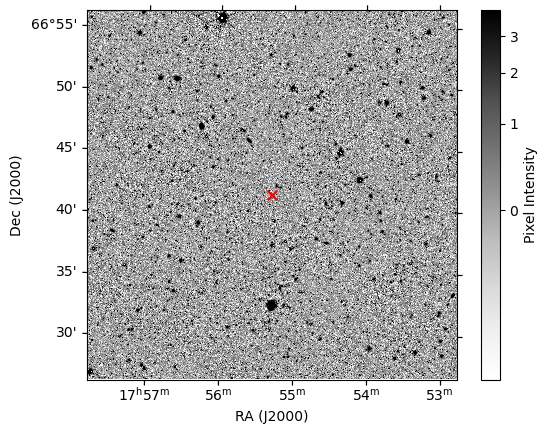

In [ ]:

# RA, Dec = 271.7185, 65.6293

RA, Dec = 268.8240562, 66.6909137

# image_path = '/Users/tutkukolcu/Documents/Notticl/Data/Q1_R1/MER/EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102158893-9493EF_20241024T213723.869646Z_00.00.fits'
# image_path = '/Users/tutkukolcu/Documents/Notticl/Data/Q1_R1/MER/EUC_MER_BGSUB-MOSAIC-VIS_TILE102158893-FE6646_20241025T014737.689392Z_00.00.fits'

image_path = '/Users/tutkukolcu/Documents/Notticl/Data/Q1_R1/MER/cutout_circle_01px.fits'
output_path = '/Users/tutkukolcu/Documents/Notticl/Data/Q1_R1/MER/' 

cutout_name = 'cutout_test_field_0.5deg.fits'

centre, image, image_header, image_wcs = get_cutout_and_save(image_path, 0.5, output_path, cutout_name, source='MER', ra=RA, dec=Dec)

print(f'Centre of the image is: RA, Dec {centre}')
show_image(image, image_wcs, centre.ra.value, centre.dec.value,)

### 2) Estimate a local background and produce a background subtracted image. 
##### These will be recreated during object mask but you can uncomment and see the example.

In [ ]:
##example
# bkg_image,bkg_image_rms, bgsub_image = estimate_local_background(image, kernel_size=9, filter_size=11 ,plot=True)


### 3) Determining threshold for bright source detection, and create the detection image
##### These will be recreated during object mask but you can uncomment and see the example.

In [ ]:
##example
# threshold, detection_image = image_threshold_convolution(bkg_image, bkg_image_rms, bgsub_image, threshold_factor=3, FWHM=3, plot=True)


## Defining masking parameters

In [ ]:

params = {
    "kernel_size": 9,
    "filter_size": 11,
    "threshold_factor": 3,
    "growth": 3,
    "FWHM":3,
    "pixel_connectivity": 6,
    "pixel_size":0.1,
    "sb_limit":28.5,  # Adjust this value around these values until you are satisfied with your BCG coverage I beleive. Change to ~28.5 for NISP ~24.7. Going fainter catches more pixels.
    "plot":True}


### 4) BCG Mask: SKIP this if working on a field image

In [ ]:
# sb_limit, pix_scale = (params["sb_limit"], params["pixel_size"]*u.arcsec)
# sb_adu_threshold = sb_to_adu(sb_limit, pix_scale)

# bcg_mask = create_bcg_mask(image, wcs=image_wcs, sb_threshold=sb_adu_threshold, bcg_pos=(BCG_RA,BCG_Dec))
# plot_mask(image, bcg_mask)


### 5) Object mask
#### Running create_object_mask will reperform all the intermediate steps, background and thresholding, by using the parameters in the params library. It may take a while
#### Set plot=True to see the intemediate plots

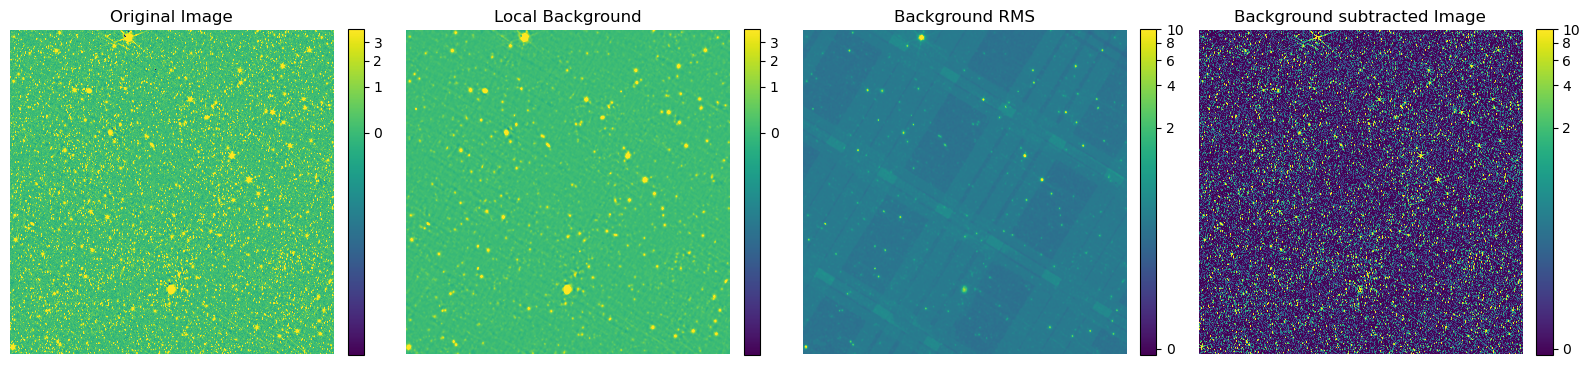

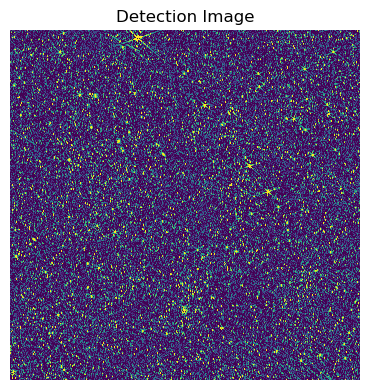

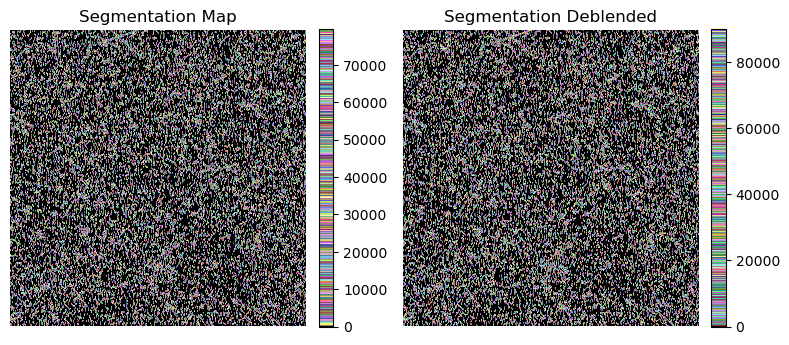

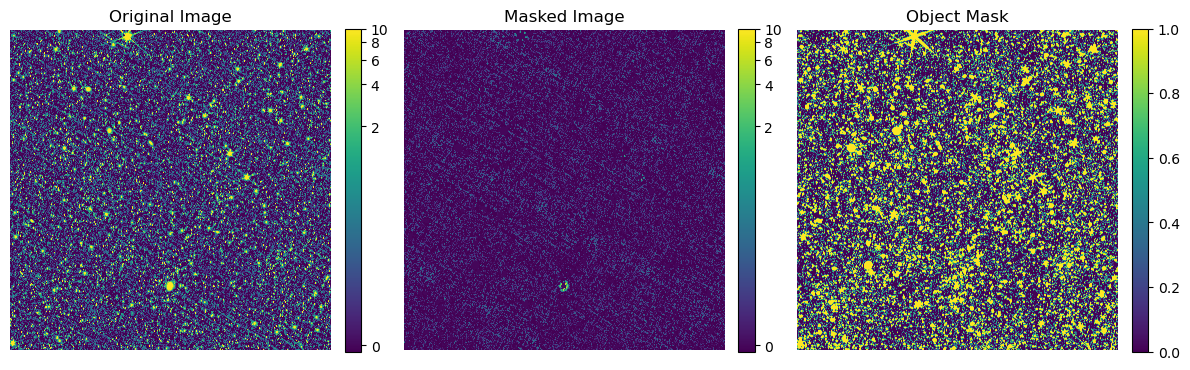

In [ ]:
object_mask = create_object_mask(image, bcg_mask=None, params= params) #None if a field image is used.
plot_mask(image, object_mask)

### 6) Faint source mask - skip if working on a field image

In [ ]:
# faint_mask, bkg, rms = create_faint_mask(image, object_mask, bcg_mask)
# plot_mask(image, faint_mask)

### The final mask - adjust whichever the mask you need in your final image.

In [ ]:
# full_mask = object_mask | faint_mask  # adding "if one is created, | bcg_mask" will remove bcg as well.

full_mask = object_mask
plot_mask(image, full_mask)

In [ ]:
output_dir  = '/Users/tutkukolcu/Documents/Notticl/Data/Q1_R1/MER/masked_images/' 
cluster_name = 'field_test2_size_0.5deg_res_0.1_' 
obs_source = 'MER'

save_masked_images_and_mask(image, full_mask, image_wcs, params, output_dir, cluster_name, obs_source)